<h1>Ising model on graphs using Metropolis algorithm</h1>

In [7]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [12]:
def total_energy(G, spins, J=1.0):
    E=0.0
    for i,j in G.edges():
        E-=J*spins[i]*spins[j]
    return E

def metropolis_sweep(G, spins, beta, J=1.0):
    N=G.number_of_nodes()
    nodes= list(G.nodes())
    np.random.shuffle(nodes)

    for i in nodes:
        neighbor_sum= sum(spins[j] for j in G.neighbors(i))
        delta_E=2*J*spins[i]*neighbor_sum

        if delta_E <= 0 or np.random.random() < np.exp(-beta *delta_E):
            spins[i] *= -1

def simulate_ising(G, T, J=1.0, n_sweeps=10000, burn_in=2000, measure_every=10):
    N = G.number_of_nodes()
    beta = 1.0 / T if T > 0 else float('inf')
    
    spins = np.random.choice([-1, 1], size=N)
    
    magnetizations = []
    energies = []
    
    for sweep in range(n_sweeps):
        metropolis_sweep(G, spins, beta, J)
        
        if sweep >= burn_in and sweep % measure_every == 0:
            m = np.mean(spins)
            E = total_energy(G, spins, J)
            magnetizations.append(m)
            energies.append(E)
    
    return np.array(magnetizations), np.array(energies)


def compute_observables(mags, energies, T, N):
    beta = 1.0 / T if T > 0 else float('inf')
    
    m_abs = np.abs(mags)
    m_mean = np.mean(m_abs)
    m2_mean = np.mean(mags**2)
    
    e = energies / N
    e_mean = np.mean(e)
    e2_mean = np.mean(e**2)
    
    chi = N * beta * (m2_mean - m_mean**2) if T > 0 else 0.0
    cv = N * beta**2 * (e2_mean - e_mean**2) if T > 0 else 0.0
    
    return {
        'm': m_mean,
        'e': e_mean,
        'chi': chi,
        'cv': cv
    }

In [ ]:

L = 10
G = nx.grid_2d_graph(L, L, periodic=True)
G = nx.convert_node_labels_to_integers(G)

N = G.number_of_nodes()
print(f"Grafo con N={N} nodi, grado medio={np.mean([d for _, d in G.degree()]):.2f}")


temperatures = np.linspace(1.5, 3.5, 15)

results = []
for T in temperatures:
    mags, energies = simulate_ising(G, T, J=1.0, n_sweeps=5000, burn_in=1000, measure_every=5)
    obs = compute_observables(mags, energies, T, N)
    results.append((T, obs))

Grafo con N=100 nodi, grado medio=4.00


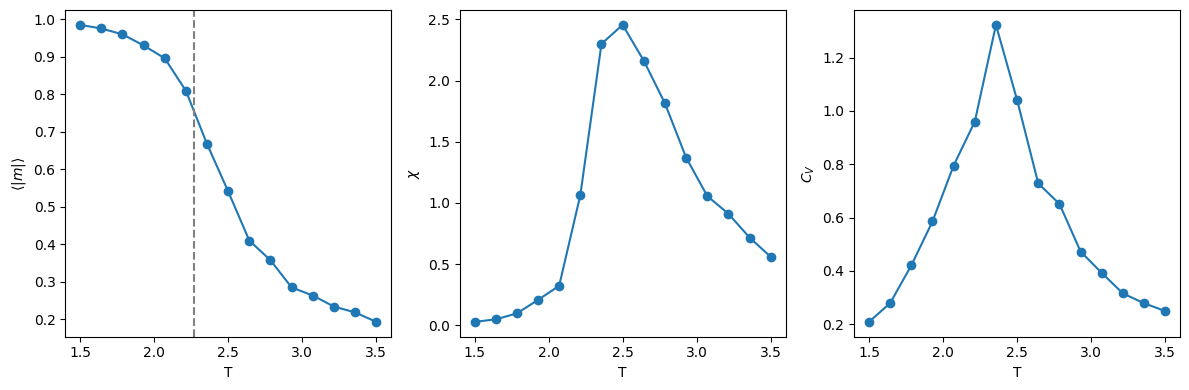

In [16]:
T_vals = [r[0] for r in results]
m_vals = [r[1]['m'] for r in results]
chi_vals = [r[1]['chi'] for r in results]
cv_vals = [r[1]['cv'] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].plot(T_vals, m_vals, 'o-')
axes[0].set_xlabel('T')
axes[0].set_ylabel(r'$\langle |m| \rangle$')
axes[0].axvline(2.269, color='gray', linestyle='--', label='Tc Onsager')  # per reticolo quadrato

axes[1].plot(T_vals, chi_vals, 'o-')
axes[1].set_xlabel('T')
axes[1].set_ylabel(r'$\chi$')

axes[2].plot(T_vals, cv_vals, 'o-')
axes[2].set_xlabel('T')
axes[2].set_ylabel(r'$C_V$')

plt.tight_layout()
plt.savefig('ising_results_10x10.pdf', format='pdf', bbox_inches='tight')
plt.show()


Simulazione su Grid 10×10: N=100, ⟨k⟩=4.00

Simulazione su Erdős–Rényi (⟨k⟩≈4): N=100, ⟨k⟩=4.18

Simulazione su Barabási–Albert (⟨k⟩≈4): N=100, ⟨k⟩=3.92


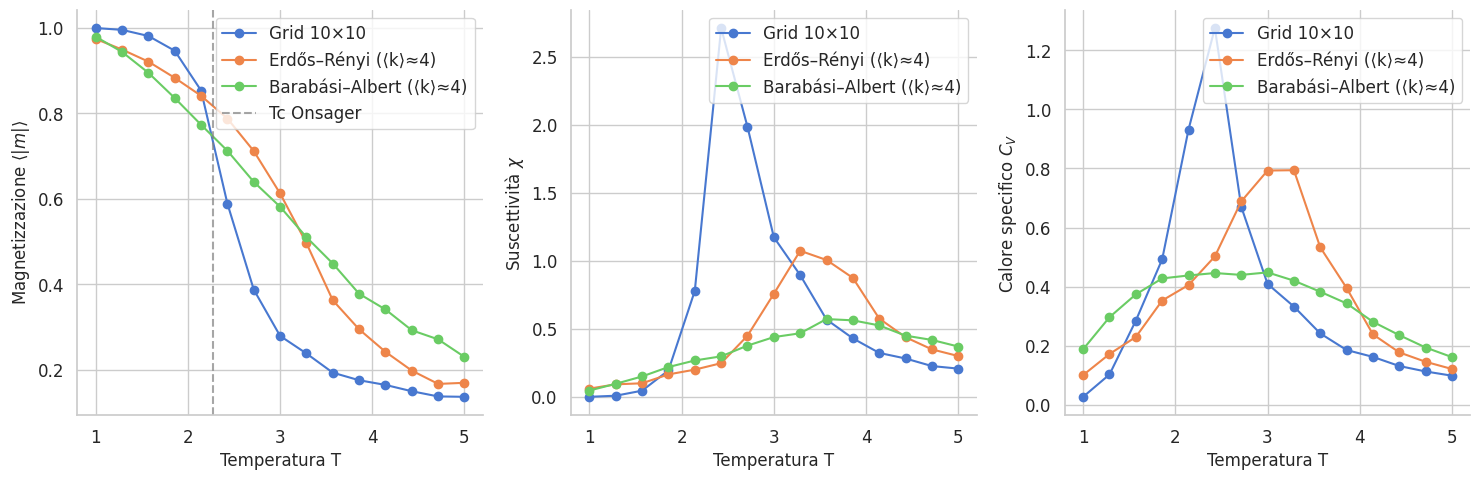


Simulazione completata. Grafico salvato come 'ising_random_graphs_seaborn.pdf'


In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)



def total_energy(G, spins, J=1.0):
    """Calcola l'energia totale H = -J * sum_{(i,j) in E} sigma_i * sigma_j"""
    E = 0.0
    for i, j in G.edges():
        E -= J * spins[i] * spins[j]
    return E


def metropolis_sweep(G, spins, beta, J=1.0):
    """
    Esegue uno sweep completo (visita ogni nodo una volta in ordine casuale).
    Modifica l'array 'spins' in-place.
    """
    N = G.number_of_nodes()
    nodes = list(G.nodes())
    np.random.shuffle(nodes)

    for i in nodes:
        neighbor_sum = sum(spins[j] for j in G.neighbors(i))
        delta_E = 2 * J * spins[i] * neighbor_sum  # h=0

        if delta_E <= 0 or np.random.random() < np.exp(-beta * delta_E):
            spins[i] *= -1


def simulate_ising(G, T, J=1.0, n_sweeps=10000, burn_in=2000, measure_every=10):
    """
    Simula il modello di Ising sul grafo G a temperatura T.
    Restituisce array di magnetizzazioni ed energie totali.
    """
    N = G.number_of_nodes()
    beta = 1.0 / T if T > 0 else float('inf')

    spins = np.random.choice([-1, 1], size=N)
    magnetizations = []
    energies = []

    for sweep in range(n_sweeps):
        metropolis_sweep(G, spins, beta, J)

        if sweep >= burn_in and sweep % measure_every == 0:
            m = np.mean(spins)
            E = total_energy(G, spins, J)
            magnetizations.append(m)
            energies.append(E)

    return np.array(magnetizations), np.array(energies)


def compute_observables(mags, energies, T, N):
    """Calcola medie, suscettività e calore specifico."""
    beta = 1.0 / T if T > 0 else float('inf')

    m_abs = np.abs(mags)
    m_mean = np.mean(m_abs)
    m2_mean = np.mean(mags**2)

    e = energies / N
    e_mean = np.mean(e)
    e2_mean = np.mean(e**2)

    chi = N * beta * (m2_mean - m_mean**2) if T > 0 else 0.0
    cv = N * beta**2 * (e2_mean - e_mean**2) if T > 0 else 0.0

    return {'m': m_mean, 'e': e_mean, 'chi': chi, 'cv': cv}



N = 100        
J = 1.0       

G_grid = nx.grid_2d_graph(10, 10, periodic=True)
G_grid = nx.convert_node_labels_to_integers(G_grid)

p = 4 / (N - 1)
G_er = nx.erdos_renyi_graph(N, p)
while not nx.is_connected(G_er):
    G_er = nx.erdos_renyi_graph(N, p)

m_ba = 2
G_ba = nx.barabasi_albert_graph(N, m_ba)

graphs = {
    'Grid 10×10': G_grid,
    'Erdős–Rényi (⟨k⟩≈4)': G_er,
    'Barabási–Albert (⟨k⟩≈4)': G_ba
}


temperatures = np.linspace(1.0, 5.0, 15)
n_sweeps = 5000
burn_in = 1000
measure_every = 5

results = {name: [] for name in graphs}

for name, G in graphs.items():
    print(f"\nSimulazione su {name}: N={G.number_of_nodes()}, "
          f"⟨k⟩={np.mean([d for _, d in G.degree()]):.2f}")
    for T in temperatures:
        mags, energies = simulate_ising(G, T, J, n_sweeps, burn_in, measure_every)
        obs = compute_observables(mags, energies, T, G.number_of_nodes())
        results[name].append((T, obs))


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = sns.color_palette("muted", n_colors=3)

for idx, (name, res) in enumerate(results.items()):
    T_vals = [r[0] for r in res]
    m_vals = [r[1]['m'] for r in res]
    chi_vals = [r[1]['chi'] for r in res]
    cv_vals = [r[1]['cv'] for r in res]

    axes[0].plot(T_vals, m_vals, 'o-', color=colors[idx], label=name, markersize=6)
    axes[1].plot(T_vals, chi_vals, 'o-', color=colors[idx], label=name, markersize=6)
    axes[2].plot(T_vals, cv_vals, 'o-', color=colors[idx], label=name, markersize=6)

axes[0].axvline(2.269, color='gray', linestyle='--', alpha=0.7, label='Tc Onsager')


axes[0].set_xlabel('Temperature T', fontsize=12)
axes[0].set_ylabel(r'Magnetisation $\langle |m| \rangle$', fontsize=12)
axes[0].legend(frameon=True)

axes[1].set_xlabel('Temperature T', fontsize=12)
axes[1].set_ylabel(r'Susceptibility $\chi$', fontsize=12)
axes[1].legend(frameon=True)

axes[2].set_xlabel('Temperature T', fontsize=12)
axes[2].set_ylabel(r'Specific heat $C_V$', fontsize=12)
axes[2].legend(frameon=True)


sns.despine()
plt.tight_layout()

# Salvataggio in PDF
plt.savefig('ising_random_graphs.pdf', bbox_inches='tight')
plt.show()


=== N = 64 ===
Grafo connesso: ⟨k⟩ = 4.88

=== N = 128 ===
Grafo connesso: ⟨k⟩ = 3.86

=== N = 256 ===
Grafo connesso: ⟨k⟩ = 4.14

=== N = 512 ===
Grafo connesso: ⟨k⟩ = 4.26


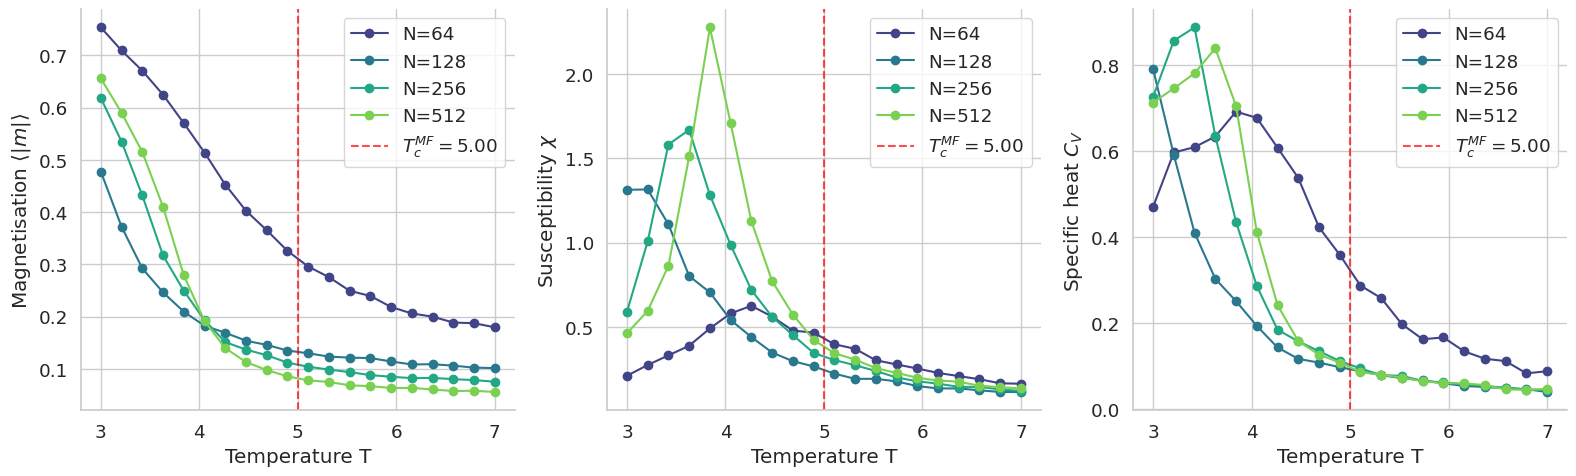

In [27]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)



def total_energy(G, spins, J=1.0):
    E = 0.0
    for i, j in G.edges():
        E -= J * spins[i] * spins[j]
    return E

def metropolis_sweep(G, spins, beta, J=1.0):
    N = G.number_of_nodes()
    nodes = list(G.nodes())
    np.random.shuffle(nodes)
    for i in nodes:
        neighbor_sum = sum(spins[j] for j in G.neighbors(i))
        delta_E = 2 * J * spins[i] * neighbor_sum
        if delta_E <= 0 or np.random.random() < np.exp(-beta * delta_E):
            spins[i] *= -1

def simulate_ising(G, T, J=1.0, n_sweeps=10000, burn_in=2000, measure_every=10):
    N = G.number_of_nodes()
    beta = 1.0 / T if T > 0 else float('inf')
    spins = np.random.choice([-1, 1], size=N)
    magnetizations = []
    energies = []
    for sweep in range(n_sweeps):
        metropolis_sweep(G, spins, beta, J)
        if sweep >= burn_in and sweep % measure_every == 0:
            magnetizations.append(np.mean(spins))
            energies.append(total_energy(G, spins, J))
    return np.array(magnetizations), np.array(energies)

def compute_observables(mags, energies, T, N):
    beta = 1.0 / T if T > 0 else float('inf')
    m_abs = np.abs(mags)
    m_mean = np.mean(m_abs)
    m2_mean = np.mean(mags**2)
    e = energies / N
    e_mean = np.mean(e)
    e2_mean = np.mean(e**2)
    chi = N * beta * (m2_mean - m_mean**2) if T > 0 else 0.0
    cv = N * beta**2 * (e2_mean - e_mean**2) if T > 0 else 0.0
    return {'m': m_mean, 'e': e_mean, 'chi': chi, 'cv': cv}


k_avg = 4              
J = 1.0
N_values = [64, 128, 256, 512]  

temperatures = np.linspace(3.0, 7.0, 20)

n_sweeps = 8000
burn_in = 2000
measure_every = 5


results = {}  

for N in N_values:
    print(f"\n=== N = {N} ===")
    p = k_avg / (N - 1)
    G = nx.erdos_renyi_graph(N, p)
    while not nx.is_connected(G):
        G = nx.erdos_renyi_graph(N, p)
    print(f"Grafo connesso: ⟨k⟩ = {np.mean([d for _,d in G.degree()]):.2f}")

    T_list = []
    m_list = []
    chi_list = []
    cv_list = []

    for T in temperatures:
        mags, energies = simulate_ising(G, T, J, n_sweeps, burn_in, measure_every)
        obs = compute_observables(mags, energies, T, N)
        T_list.append(T)
        m_list.append(obs['m'])
        chi_list.append(obs['chi'])
        cv_list.append(obs['cv'])

    results[N] = {
        'T': np.array(T_list),
        'm': np.array(m_list),
        'chi': np.array(chi_list),
        'cv': np.array(cv_list)
    }


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

palette = sns.color_palette("viridis", n_colors=len(N_values))

for i, N in enumerate(N_values):
    data = results[N]
    axes[0].plot(data['T'], data['m'], 'o-', color=palette[i], label=f'N={N}', markersize=6)
    axes[1].plot(data['T'], data['chi'], 'o-', color=palette[i], label=f'N={N}', markersize=6)
    axes[2].plot(data['T'], data['cv'], 'o-', color=palette[i], label=f'N={N}', markersize=6)

# Tc from mean field theory
Tc_mf = J * (k_avg + 1)
for ax in axes:
    ax.axvline(Tc_mf, color='red', linestyle='--', alpha=0.7, label=f'$T_c^{{MF}}={Tc_mf:.2f}$')


axes[0].set_xlabel('Temperature T')
axes[0].set_ylabel(r'Magnetisation $\langle |m| \rangle$')
axes[0].legend()

axes[1].set_xlabel('Temperature T')
axes[1].set_ylabel(r'Susceptibility $\chi$')
axes[1].legend()

axes[2].set_xlabel('Temperature T')
axes[2].set_ylabel(r'Specific heat $C_V$')
axes[2].legend()

sns.despine()
plt.tight_layout()
plt.savefig('er_scaling_N.pdf', bbox_inches='tight')
plt.show()